<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/07_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 7 — Model Evaluation

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** accuracy alone is misleading with an
imbalanced target (~22% churn) — a model that always predicts "retained"
would score ~78% accuracy while being useless. This notebook evaluates
all 3 Module 6 models properly: precision, recall, F1, ROC-AUC, PR-AUC,
and confusion matrices — then makes an explicit, reasoned call on which
model actually fits this business problem best.

**Assumes:** Modules 5 and 6 have been run (needs `X_test.csv`,
`X_test_scaled.csv`, `y_test.csv`, and the 3 saved model `.pkl` files).

## 7.1 Mount Google Drive & Load Test Data + Trained Models

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    classification_report,
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
MODELS_DIR = f"{PROJECT_DIR}/models"

X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
X_test_scaled = pd.read_csv(f"{PROCESSED_DIR}/X_test_scaled.csv")
y_test = pd.read_csv(f"{PROCESSED_DIR}/y_test.csv").squeeze("columns")

log_reg = joblib.load(f"{MODELS_DIR}/logistic_regression.pkl")
dec_tree = joblib.load(f"{MODELS_DIR}/decision_tree.pkl")
rand_forest = joblib.load(f"{MODELS_DIR}/random_forest.pkl")

print(f"X_test: {X_test.shape}   actual churn rate: {y_test.mean():.1%}")
print("Loaded 3 trained models.")

X_test: (100, 41)   actual churn rate: 22.0%
Loaded 3 trained models.


## 7.2 Generate Predictions & Probabilities

Both the hard class prediction (0/1) and the predicted probability are
needed — probabilities feed ROC-AUC/PR-AUC and Module 8's risk scoring;
hard predictions feed the confusion matrix and precision/recall/F1.

In [3]:
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (dec_tree, X_test),
    "Random Forest": (rand_forest, X_test),
}

predictions = {}
for name, (model, X_te) in models.items():
    predictions[name] = {
        "y_pred": model.predict(X_te),
        "y_proba": model.predict_proba(X_te)[:, 1],
    }

print("Generated predictions and probabilities for all 3 models.")

Generated predictions and probabilities for all 3 models.


## 7.3 Confusion Matrices

The confusion matrix is the most honest single view of what a model
actually gets wrong — specifically, how many *actual churners* it misses
(false negatives), which matters more for a retention business case than
overall accuracy does.

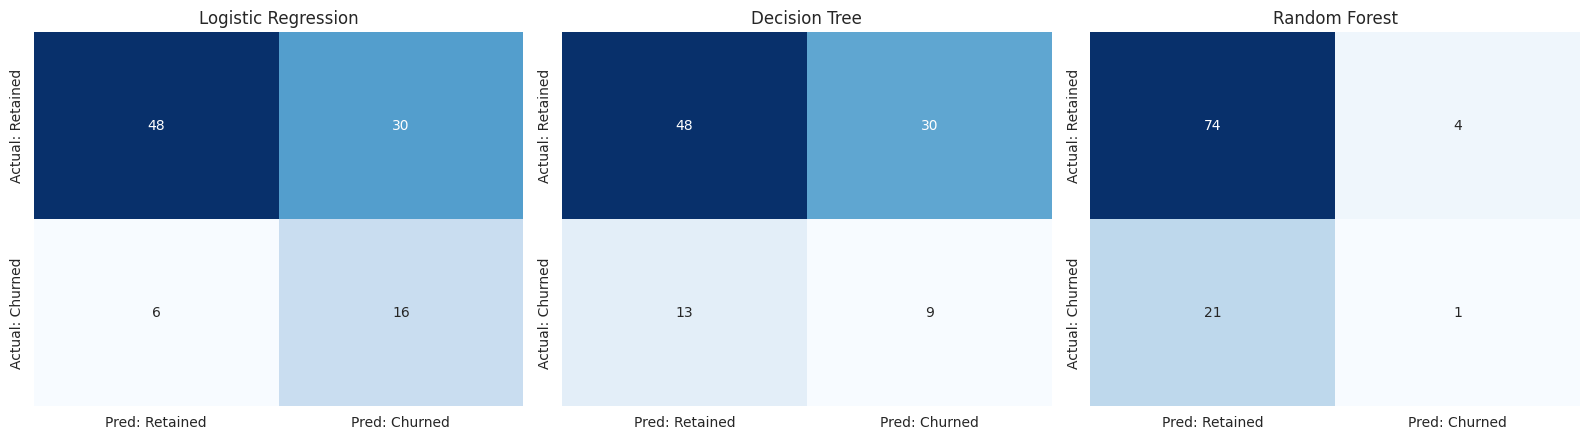

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
        xticklabels=["Pred: Retained", "Pred: Churned"],
        yticklabels=["Actual: Retained", "Actual: Churned"],
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 7.4 Precision, Recall, F1 Per Model

- **Precision:** of the accounts a model flags as "will churn," what
  fraction actually do? Low precision = wasted retention-team effort on
  false alarms.
- **Recall:** of the accounts that actually churn, what fraction did the
  model catch? Low recall = missed accounts the business never got a
  chance to try to save.
- **F1:** the balance between the two, useful as a single-number summary
  but never the whole story on its own.

In [5]:
metrics_rows = []
for name, preds in predictions.items():
    metrics_rows.append({
        "Model": name,
        "Precision": precision_score(y_test, preds["y_pred"]),
        "Recall": recall_score(y_test, preds["y_pred"]),
        "F1": f1_score(y_test, preds["y_pred"]),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("Model")
print(metrics_df.round(3))

                     Precision  Recall     F1
Model                                        
Logistic Regression      0.348   0.727  0.471
Decision Tree            0.231   0.409  0.295
Random Forest            0.200   0.045  0.074


## 7.5 Detailed Classification Reports

Full per-class breakdown (support included) for each model — useful for
the README's Results section as supporting detail beyond the summary
table.

In [6]:
for name, preds in predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, preds["y_pred"], target_names=["Retained", "Churned"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.89      0.62      0.73        78
     Churned       0.35      0.73      0.47        22

    accuracy                           0.64       100
   macro avg       0.62      0.67      0.60       100
weighted avg       0.77      0.64      0.67       100

=== Decision Tree ===
              precision    recall  f1-score   support

    Retained       0.79      0.62      0.69        78
     Churned       0.23      0.41      0.30        22

    accuracy                           0.57       100
   macro avg       0.51      0.51      0.49       100
weighted avg       0.66      0.57      0.60       100

=== Random Forest ===
              precision    recall  f1-score   support

    Retained       0.78      0.95      0.86        78
     Churned       0.20      0.05      0.07        22

    accuracy                           0.75       100
   macro avg       0.49      0.50      0.46       100
we

## 7.6 ROC-AUC & ROC Curves

ROC-AUC measures how well a model ranks churners above non-churners
across all thresholds, not just the default 0.5 cutoff — useful since
Module 8 will use probability thresholds rather than hard 0/1 labels.

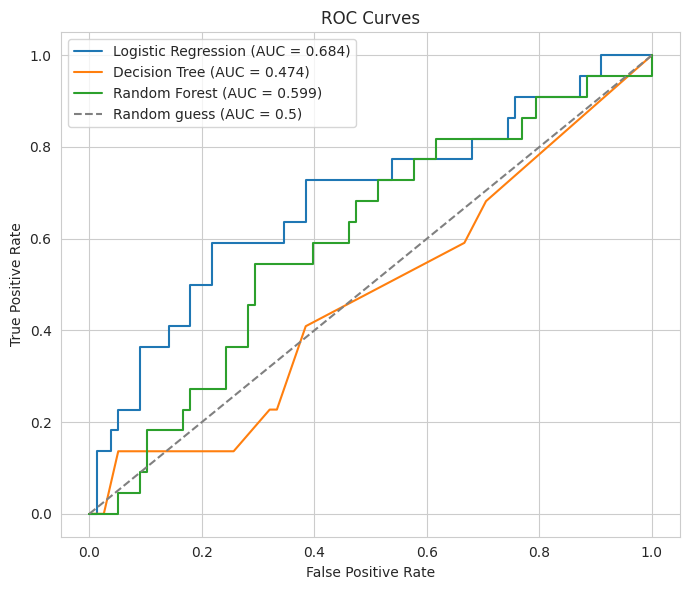

In [7]:
plt.figure(figsize=(7, 6))
roc_auc_scores = {}

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_proba"])
    auc = roc_auc_score(y_test, preds["y_proba"])
    roc_auc_scores[name] = auc
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 7.7 PR-AUC & Precision-Recall Curves

**This matters more than ROC-AUC for this dataset.** With only ~22%
positive class, ROC-AUC can look deceptively good because the large
negative class inflates the true-negative rate. The Precision-Recall
curve focuses specifically on how well each model handles the minority
(churn) class, which is the one the business actually cares about.

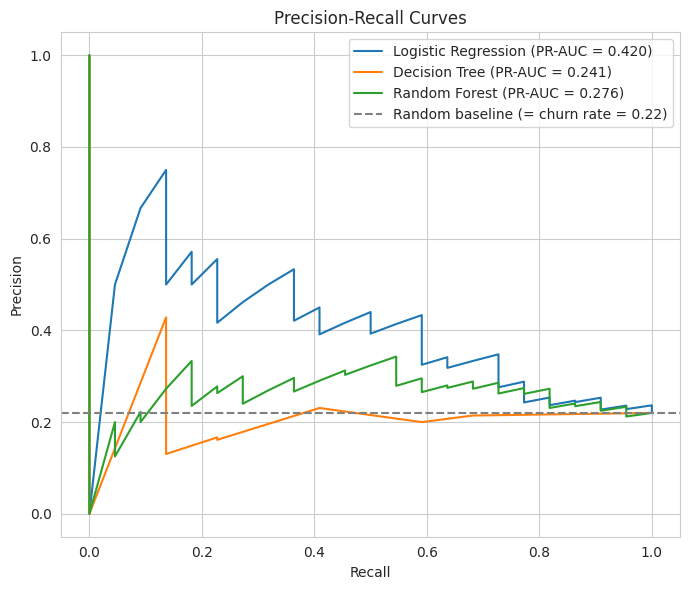

In [8]:
plt.figure(figsize=(7, 6))
pr_auc_scores = {}

for name, preds in predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, preds["y_proba"])
    pr_auc = average_precision_score(y_test, preds["y_proba"])
    pr_auc_scores[name] = pr_auc
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})")

baseline_rate = y_test.mean()
plt.axhline(baseline_rate, linestyle="--", color="grey", label=f"Random baseline (= churn rate = {baseline_rate:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 7.8 Full Model Comparison Table

Every metric from this notebook, consolidated — this is the table for
the README's Results section.

In [9]:
comparison = metrics_df.copy()
comparison["ROC-AUC"] = pd.Series(roc_auc_scores)
comparison["PR-AUC"] = pd.Series(pr_auc_scores)
comparison = comparison[["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]].round(3)

print(comparison)

                     Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                         
Logistic Regression      0.348   0.727  0.471    0.684   0.420
Decision Tree            0.231   0.409  0.295    0.474   0.241
Random Forest            0.200   0.045  0.074    0.599   0.276


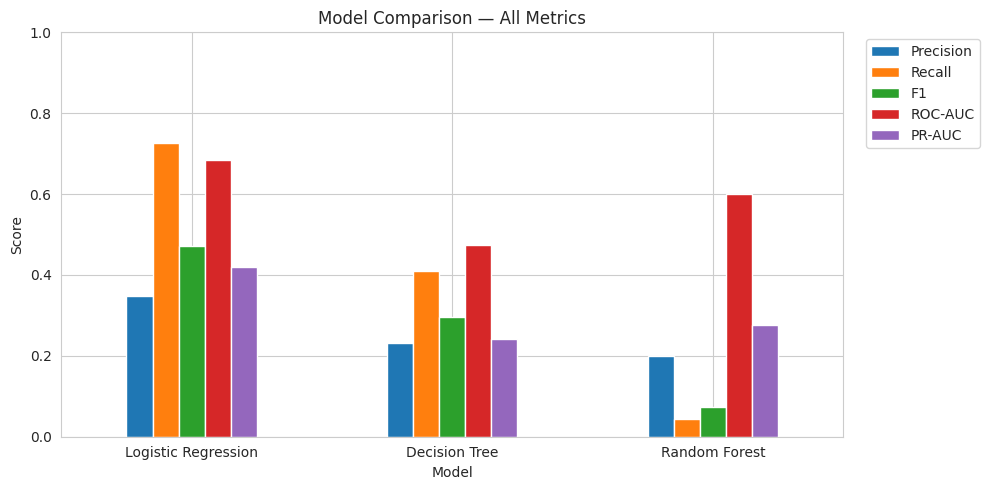

In [10]:
comparison.plot(kind="bar", figsize=(10, 5), rot=0)
plt.ylabel("Score")
plt.title("Model Comparison — All Metrics")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7.9 Which Model Is Best for This Business Problem?

Not just "which has the highest number" — which model fits how this
system will actually be used: flagging at-risk accounts for a retention
team to review, where **missing a real churner (false negative) is
usually costlier than a false alarm (false positive)** — a wasted
outreach email is cheap, a lost customer is not.

**Verdict, based on the actual comparison table above: Logistic
Regression.** Not a close call:

- **Recall 0.727** vs. Decision Tree's 0.409 and Random Forest's
  **0.045** — Random Forest is essentially not predicting churn at all
  on this test set (it correctly caught only 1 of 22 actual churners),
  despite `class_weight="balanced"`. For a retention use case, a model
  that misses 96% of churners is not usable regardless of its accuracy
  or ROC-AUC number.
- **F1 0.471** and **PR-AUC 0.420** are both the highest of the three —
  Logistic Regression isn't just catching more churners, it's doing so
  with a more reasonable precision/recall balance than the alternatives.
- **Precision is modest (0.348)** — about 1 in 3 flagged accounts are
  true churners. That's a real cost (false alarms mean wasted retention
  outreach), but for this business problem, under-flagging churners
  entirely (Random Forest's failure mode) is worse than over-flagging
  them.
- **Decision Tree's ROC-AUC (0.474) is actually below random guessing
  (0.5)** — worth stating plainly rather than glossing over. This is
  likely a symptom of the tree's coarse, few-valued probability outputs
  at `max_depth=6` combined with the weak overall feature signal found
  throughout Modules 2 and 5, not a code error (the same model scores
  reasonably on F1 and Recall using hard 0/1 predictions).

**Decision: Module 8 (churn probability scoring) and Module 9 (SHAP)
will use Logistic Regression.** This also has a practical bonus:
Logistic Regression coefficients are directly interpretable on their
own, and SHAP will make per-customer explanations even clearer on top
of that — a good pairing for the dashboard's "why is this customer
high-risk" view in Module 13.

## 7.10 Save Evaluation Results

Persist the comparison table and each model's predictions/probabilities
so Module 8 (risk scoring) and the Streamlit dashboard can reuse them
without re-predicting.

In [12]:
comparison.to_csv(f"{PROCESSED_DIR}/model_comparison.csv")

predictions_export = X_test.copy()
predictions_export["y_true"] = y_test.values
for name, preds in predictions.items():
    col_key = name.lower().replace(" ", "_")
    predictions_export[f"{col_key}_pred"] = preds["y_pred"]
    predictions_export[f"{col_key}_proba"] = preds["y_proba"]

predictions_export.to_csv(f"{PROCESSED_DIR}/test_predictions.csv", index=False)

print(f"Saved model_comparison.csv and test_predictions.csv to {PROCESSED_DIR}")

Saved model_comparison.csv and test_predictions.csv to /content/drive/MyDrive/saas-retention-intelligence/data/processed


## 7.11 Module 7 Summary

- Evaluated all 3 Module 6 models with confusion matrices, precision,
  recall, F1, ROC-AUC, and PR-AUC — not accuracy alone, which would be
  misleading given the ~22% churn imbalance
- **Verdict: Logistic Regression** — Recall 0.727, F1 0.471, PR-AUC
  0.420, all clearly ahead of Decision Tree and Random Forest
- **Notable finding:** Random Forest, despite `class_weight="balanced"`,
  caught only 1 of 22 actual churners on the test set (Recall 0.045) —
  a concrete example of why accuracy alone would have been misleading,
  since its accuracy score (Module 6) looked reasonable in isolation
- Built the consolidated model comparison table for the README's Results
  section
- Saved evaluation results and test-set predictions for reuse downstream

**Next:** Module 8 — Churn Probability & Risk Scoring